# Baseline Portfolio Optimization Experiment

**Research stage:** risk-focused baseline for a portfolio-allocation study  
**Primary comparison:** naive 1/N versus constrained Ledoit–Wolf shrinkage GMV  
**Evaluation design:** validation-only configuration selection followed by a locked walk-forward test

This notebook is designed as a reproducible research artifact. It implements point-in-time universe selection, drift-adjusted turnover, proportional transaction costs, statistical uncertainty, and explicit leakage checks. It does not forecast expected returns and does not implement the later regime-aware, fundamental, or machine-learning extensions.

## TL;DR

Validation selects a 252-day, monthly, 15%-capped specification. On the locked test period, Shrinkage GMV reduces annualized volatility from 16.92% to 13.21%, daily CVaR 95% from 2.41% to 1.86%, and maximum drawdown from 20.67% to 18.67% relative to 1/N. The trade-off is a 0.040 lower Sharpe ratio, 3.17 annualized turnover, and 1.62% cumulative modeled trading costs. Paired block-bootstrap intervals support the volatility and CVaR reductions, while the drawdown and risk-adjusted-return differences remain uncertain; the evidence therefore supports a stable risk-focused control, not unconditional superiority.

## 1. Research Objective

The objective is to determine whether a constrained global minimum-variance portfolio estimated with Ledoit–Wolf covariance shrinkage provides a stable out-of-sample risk baseline relative to equal weighting. The GMV objective is

\[
\min_w\; w^\top \widehat{\Sigma}_{LW} w
\quad\text{subject to}\quad
\mathbf{1}^\top w=1,\; 0\leq w_i\leq \bar{w}.
\]

No expected-return forecast enters the optimization. CVaR is an out-of-sample tail-risk metric, not the allocation objective. An unregularized sample-covariance GMV portfolio is included only as a diagnostic for the effect of shrinkage.

## 2. Experimental Design

- **Train:** establishes the initial historical estimation sample.
- **Validation:** selects a compact set of implementation choices using a risk-focused composite score.
- **Test:** remains excluded from selection and is used only after the configuration is frozen.
- **Walk-forward timing:** weights effective on date \(t\) use returns dated strictly before \(t\), then earn date-\(t\) returns.
- **Universe:** eligibility is recomputed at every formation date from trailing observations only.
- **Costs:** two-sided L1 turnover, \(\sum_i |w_{i,t}-w^{pre}_{i,t-1}|\), is calculated against drifted pre-trade weights; 10 bps is charged per dollar traded by default.
- **Return convention:** log returns support distribution diagnostics; simple returns drive covariance estimation, portfolio drift, realized performance, and transaction-cost accounting.

The available files are a balanced 50-security panel, which cannot represent historical constituents that disappeared before data construction. Consequently, point-in-time eligibility is enforced within the supplied panel, but complete elimination of survivorship bias is not possible from these files alone.

## 3. Imports and Configuration

In [1]:
from __future__ import annotations

import os
import tempfile
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Iterable, Literal

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "baseline-matplotlib-cache")
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

SEED = 20260830
TRADING_DAYS = 252
RNG = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 5.5),
        "figure.dpi": 110,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.frameon": False,
    }
)

In [2]:
@dataclass(frozen=True)
class BacktestConfig:
    """All implementation choices needed by the walk-forward engine."""

    lookback: int
    rebalance: Literal["M", "Q"]
    max_weight: float
    min_observations: int
    max_missing_fraction: float = 0.05
    transaction_cost_bps: float = 10.0

    @property
    def cost_rate(self) -> float:
        return self.transaction_cost_bps / 10_000.0

    @property
    def label(self) -> str:
        return (
            f"LB{self.lookback}_{self.rebalance}_"
            f"CAP{int(round(self.max_weight * 100)):02d}"
        )


@dataclass
class BacktestResult:
    """Container for a fully auditable strategy backtest."""

    strategy: str
    config: BacktestConfig
    returns: pd.DataFrame
    target_weights: pd.DataFrame
    diagnostics: pd.DataFrame


# Manually set any entry only if automatic schema detection is inappropriate.
SCHEMA_OVERRIDES = {
    "date": None,
    "asset": None,
    "price": None,
    "return": None,
}

DATA_DIRECTORY_CANDIDATES = [Path("/data"), Path.cwd() / "data"]
SPLIT_FILENAMES = {"train": "train.csv", "validation": "val.csv", "test": "test.csv"}

# Compact candidate set: a full monthly lookback/cap grid plus one quarterly anchor.
CANDIDATE_CONFIGS = [
    BacktestConfig(
        lookback=lookback,
        rebalance="M",
        max_weight=max_weight,
        min_observations=int(np.ceil(0.80 * lookback)),
    )
    for lookback in (126, 252, 504)
    for max_weight in (0.10, 0.15, 0.20)
] + [
    BacktestConfig(
        lookback=252,
        rebalance="Q",
        max_weight=0.15,
        min_observations=int(np.ceil(0.80 * 252)),
    )
]

print(f"Random seed: {SEED}")
print(f"Candidate configurations: {len(CANDIDATE_CONFIGS)}")
display(pd.DataFrame(asdict(config) for config in CANDIDATE_CONFIGS))

Random seed: 20260830
Candidate configurations: 10


,lookback,rebalance,max_weight,min_observations,max_missing_fraction,transaction_cost_bps
0,126,M,0.10,101,0.05,10.0
1,126,M,0.15,101,0.05,10.0
2,126,M,0.20,101,0.05,10.0
3,252,M,0.10,202,0.05,10.0
4,252,M,0.15,202,0.05,10.0
5,252,M,0.20,202,0.05,10.0
6,504,M,0.10,404,0.05,10.0
7,504,M,0.15,404,0.05,10.0
8,504,M,0.20,404,0.05,10.0
9,252,Q,0.15,202,0.05,10.0


## 4. Data Loading and Schema Inspection

Schema inference is deliberately separate from data preparation. Candidate names are normalized, preferred adjusted-price fields outrank unadjusted close, and ambiguous matches at the same priority raise an error. The repository-local `data/` directory is a portable fallback for environments where the specification's `/data` mount is unavailable.

In [3]:
def normalize_column_name(column: str) -> str:
    """Normalize a column name for conservative schema matching."""
    return "".join(character for character in column.lower() if character.isalnum())


def choose_unique_candidate(
    columns: Iterable[str], priority_groups: list[set[str]], field: str
) -> str | None:
    """Choose the unique highest-priority schema candidate or fail on ambiguity."""
    normalized = {column: normalize_column_name(column) for column in columns}
    for group in priority_groups:
        matches = [column for column, token in normalized.items() if token in group]
        if len(matches) == 1:
            return matches[0]
        if len(matches) > 1:
            raise ValueError(
                f"Ambiguous {field} columns at the same priority: {matches}. "
                f"Set SCHEMA_OVERRIDES['{field}'] explicitly."
            )
    return None


def detect_schema(frame: pd.DataFrame) -> dict[str, str | None]:
    """Infer long-form date, asset, adjusted price, and optional return fields."""
    detected = {
        "date": choose_unique_candidate(
            frame.columns,
            [{"date", "datetime", "timestamp", "tradedate", "pricedate"}],
            "date",
        ),
        "asset": choose_unique_candidate(
            frame.columns,
            [{"ticker", "symbol", "asset", "assetid", "security", "ric"}],
            "asset",
        ),
        "price": choose_unique_candidate(
            frame.columns,
            [
                {"adjclose", "adjustedclose", "adjustedprice", "adjprice"},
                {"totalreturnadjustedprice", "totalreturnprice", "tradjustedprice"},
                {"close", "closeprice", "price"},
            ],
            "price",
        ),
        "return": choose_unique_candidate(
            frame.columns,
            [{"return", "returns", "ret", "simplereturn", "logreturn"}],
            "return",
        ),
    }
    for field, override in SCHEMA_OVERRIDES.items():
        if override is not None:
            if override not in frame.columns:
                raise KeyError(f"Schema override {override!r} is not present in the data.")
            detected[field] = override

    if detected["date"] is None:
        raise ValueError("No unambiguous date/timestamp column was detected.")
    if detected["asset"] is None:
        raise ValueError(
            "No asset identifier was detected. Wide-form support requires an explicit "
            "schema extension; refusing to guess."
        )
    if detected["price"] is None and detected["return"] is None:
        raise ValueError("Neither a valid price field nor a return field was detected.")
    return detected


def resolve_data_directory() -> Path:
    """Find a directory containing all three immutable source files."""
    for candidate in DATA_DIRECTORY_CANDIDATES:
        if all((candidate / filename).is_file() for filename in SPLIT_FILENAMES.values()):
            return candidate.resolve()
    searched = ", ".join(str(path) for path in DATA_DIRECTORY_CANDIDATES)
    raise FileNotFoundError(f"Could not locate all split files. Searched: {searched}")


DATA_DIR = resolve_data_directory()
raw_splits = {
    split: pd.read_csv(DATA_DIR / filename)
    for split, filename in SPLIT_FILENAMES.items()
}
detected_schemas = {split: detect_schema(frame) for split, frame in raw_splits.items()}

if len({tuple(schema.items()) for schema in detected_schemas.values()}) != 1:
    raise ValueError(f"Split schemas are inconsistent: {detected_schemas}")

SCHEMA = detected_schemas["train"]
print(f"Resolved immutable source directory: {DATA_DIR}")
print(f"Detected format: long (one date-asset observation per row)")
print(f"Selected fields: {SCHEMA}")

Resolved immutable source directory: /Users/konstantinmelnikov/Desktop/work/portfolio optimization/data
Detected format: long (one date-asset observation per row)
Selected fields: {'date': 'Date', 'asset': 'Ticker', 'price': 'Adj Close', 'return': None}


In [4]:
def inspection_summary(split: str, frame: pd.DataFrame, schema: dict) -> dict:
    """Return high-signal structural diagnostics without mutating the source frame."""
    parsed_dates = pd.to_datetime(frame[schema["date"]], errors="coerce")
    return {
        "split": split,
        "rows": len(frame),
        "columns": frame.shape[1],
        "format": "long",
        "date_min": parsed_dates.min(),
        "date_max": parsed_dates.max(),
        "unique_assets": frame[schema["asset"]].nunique(dropna=True),
        "exact_duplicates": int(frame.duplicated().sum()),
        "date_asset_duplicates": int(
            frame.duplicated([schema["date"], schema["asset"]]).sum()
        ),
        "missing_cells": int(frame.isna().sum().sum()),
    }


inspection_table = pd.DataFrame(
    inspection_summary(split, frame, detected_schemas[split])
    for split, frame in raw_splits.items()
).set_index("split")
display(inspection_table)

for split, frame in raw_splits.items():
    print(f"\n{split.upper()} — shape={frame.shape}, columns={list(frame.columns)}")
    display(frame.head())
    display(
        pd.DataFrame(
            {"dtype": frame.dtypes.astype(str), "missing": frame.isna().sum()}
        )
    )

observation_counts = pd.concat(
    {
        split: frame.groupby(SCHEMA["asset"], observed=True).size()
        for split, frame in raw_splits.items()
    },
    axis=1,
)
print("Unique assets/tickers:")
print(", ".join(sorted(raw_splits["train"][SCHEMA["asset"]].astype(str).unique())))
print("Observations per asset and split:")
display(observation_counts)

,rows,columns,format,date_min,date_max,unique_assets,exact_duplicates,date_asset_duplicates,missing_cells
split,,,,,,,,,
train,213850,3,long,2000-01-03,2016-12-30,50,0,0,0
validation,50350,3,long,2017-01-03,2020-12-31,50,0,0,0
test,64450,3,long,2021-01-04,2026-02-20,50,0,0,0



TRAIN — shape=(213850, 3), columns=['Ticker', 'Date', 'Adj Close']


,Ticker,Date,Adj Close
0,A,2000-01-03,43.04
1,A,2000-01-04,39.75
2,A,2000-01-05,37.28
3,A,2000-01-06,35.86
4,A,2000-01-07,38.85


,dtype,missing
Ticker,object,0
Date,object,0
Adj Close,float64,0



VALIDATION — shape=(50350, 3), columns=['Ticker', 'Date', 'Adj Close']


...


TEST — shape=(64450, 3), columns=['Ticker', 'Date', 'Adj Close']


,Ticker,Date,Adj Close
0,A,2021-01-04,114.66
1,A,2021-01-05,115.60
2,A,2021-01-06,118.77
3,A,2021-01-07,121.93
4,A,2021-01-08,122.80


,dtype,missing
Ticker,object,0
Date,object,0
Adj Close,float64,0


Unique assets/tickers:
A, AAPL, ABT, ACGL, ADBE, ADI, ADP, AEE, AEP, AES, AFL, AIG, AJG, AKAM, ALB, ALL, AMAT, AMD, AME, AMGN, AMT, AMZN, APA, APD, APH, ARE, ATO, AVB, AVY, AXP, AZO, BA, BAC, BALL, BAX, BBWI, BBY, BEN, BIIB, BIO, BK, BKNG, BKR, BLK, BMY, BRK.B, BRO, BSX, BWA, C
Observations per asset and split:


,train,validation,test
Ticker,,,
A,4277,1007,1289
AAPL,4277,1007,1289
ABT,4277,1007,1289
ACGL,4277,1007,1289
ADBE,4277,1007,1289
ADI,4277,1007,1289
ADP,4277,1007,1289
AEE,4277,1007,1289
AEP,4277,1007,1289


## 5. Data Quality and Temporal Integrity

In [5]:
def prepare_long_data(frame: pd.DataFrame, schema: dict) -> pd.DataFrame:
    """Parse and standardize a long-form split without imputing or dropping anomalies."""
    output = frame.rename(
        columns={schema["date"]: "date", schema["asset"]: "asset"}
    ).copy()
    output["date"] = pd.to_datetime(output["date"], errors="raise")
    output["asset"] = output["asset"].astype(str).str.strip()
    if schema["price"] is not None:
        output = output.rename(columns={schema["price"]: "price"})
        output["price"] = pd.to_numeric(output["price"], errors="raise")
    if schema["return"] is not None:
        output = output.rename(columns={schema["return"]: "provided_return"})
        output["provided_return"] = pd.to_numeric(
            output["provided_return"], errors="raise"
        )
    return output.sort_values(["date", "asset"]).reset_index(drop=True)


clean_splits = {
    split: prepare_long_data(frame, detected_schemas[split])
    for split, frame in raw_splits.items()
}

split_ranges = pd.DataFrame(
    {
        split: {
            "start": frame["date"].min(),
            "end": frame["date"].max(),
            "assets": frame["asset"].nunique(),
            "rows": len(frame),
        }
        for split, frame in clean_splits.items()
    }
).T
display(split_ranges)

assert split_ranges.loc["train", "end"] < split_ranges.loc["validation", "start"], (
    "Train and validation periods overlap or are not chronological."
)
assert split_ranges.loc["validation", "end"] < split_ranges.loc["test", "start"], (
    "Validation and test periods overlap or are not chronological."
)

split_asset_sets = {
    split: set(frame["asset"].unique()) for split, frame in clean_splits.items()
}
asset_change_report = pd.DataFrame(
    [
        {
            "boundary": "train → validation",
            "disappeared": sorted(split_asset_sets["train"] - split_asset_sets["validation"]),
            "appeared": sorted(split_asset_sets["validation"] - split_asset_sets["train"]),
        },
        {
            "boundary": "validation → test",
            "disappeared": sorted(split_asset_sets["validation"] - split_asset_sets["test"]),
            "appeared": sorted(split_asset_sets["test"] - split_asset_sets["validation"]),
        },
    ]
)
display(asset_change_report)

,start,end,assets,rows
train,2000-01-03 00:00:00,2016-12-30 00:00:00,50,213850
validation,2017-01-03 00:00:00,2020-12-31 00:00:00,50,50350
test,2021-01-04 00:00:00,2026-02-20 00:00:00,50,64450


,boundary,disappeared,appeared
0,train → validation,[],[]
1,validation → test,[],[]


In [6]:
def longest_true_run(values: pd.Series) -> int:
    """Return the longest consecutive run of True values."""
    groups = values.ne(values.shift(fill_value=False)).cumsum()
    true_runs = values.groupby(groups).sum()
    return int(true_runs.max()) if len(true_runs) else 0


def quality_report_for_split(split: str, frame: pd.DataFrame) -> list[dict]:
    """Build compact data-quality evidence at the intended date-asset grain."""
    prices = frame.pivot(index="date", columns="asset", values="price").sort_index()
    returns = prices.pct_change(fill_method=None)
    stacked_returns = returns.stack()
    date_gaps = prices.index.to_series().diff().dt.days.dropna()
    stale_mask = prices.diff().eq(0)
    max_stale_run = max(longest_true_run(stale_mask[column]) for column in prices)
    obs_counts = frame.groupby("asset", observed=True).size()
    checks = [
        ("duplicate date-asset keys", int(frame.duplicated(["date", "asset"]).sum()), "pass"),
        ("missing prices", int(frame["price"].isna().sum()), "pass"),
        ("non-positive prices", int(frame["price"].le(0).sum()), "pass"),
        ("panel missing cells", int(prices.isna().sum().sum()), "pass"),
        ("absolute returns > 20%", int(stacked_returns.abs().gt(0.20).sum()), "review"),
        ("absolute returns > 50%", int(stacked_returns.abs().gt(0.50).sum()), "review"),
        ("stale price transitions", int(stale_mask.sum().sum()), "review"),
        ("longest stale run", max_stale_run, "review"),
        ("maximum calendar gap (days)", int(date_gaps.max()), "review"),
        ("minimum observations per asset", int(obs_counts.min()), "pass"),
    ]
    records = []
    for check, value, default_status in checks:
        status = default_status
        if check in {
            "duplicate date-asset keys",
            "missing prices",
            "non-positive prices",
            "panel missing cells",
        } and value > 0:
            status = "fail"
        if check == "minimum observations per asset" and value < 100:
            status = "fail"
        records.append({"split": split, "check": check, "value": value, "status": status})
    return records


data_quality_report = pd.DataFrame(
    record
    for split, frame in clean_splits.items()
    for record in quality_report_for_split(split, frame)
)
print("Data Quality Report")
display(data_quality_report.pivot(index="check", columns="split", values=["value", "status"]))

failed_checks = data_quality_report.query("status == 'fail'")
if not failed_checks.empty:
    raise ValueError(
        "Material data-quality checks failed; the notebook refuses implicit cleaning.\n"
        + failed_checks.to_string(index=False)
    )

print(
    "Cleaning policy: parse and sort only. No observations are removed, winsorized, "
    "forward-filled, or backfilled. Extreme returns and stale transitions remain in the sample."
)

Data Quality Report


value                   status                   
split                           test train validation    test   train validation
check                                                                           
absolute returns > 20%             9   234         28  review  review     review
absolute returns > 50%             0     6          1  review  review     review
duplicate date-asset keys          0     0          0    pass    pass       pass
longest stale run                  2    11          2  review  review     review
maximum calendar gap (days)        4     7          4  review  review     review
minimum observations per asset  1289  4277       1007    pass    pass       pass
missing prices                     0     0          0    pass    pass       pass
non-positive prices                0     0          0    pass    pass       pass
panel missing cells                0     0          0    pass    pass       pass
stale price transitions          231  5217        391  review  review     review

Cleaning policy: parse and sort only. No observations are removed, winsorized, forward-filled, or backfilled. Extreme returns and stale transitions remain in the sample.


## 6. Return Construction

Adjusted close is available and therefore takes precedence over direct-return fields. Prices are concatenated only to calculate legitimate split-boundary returns (for example, the first validation return uses the last training price). Log returns are used for diagnostics; simple returns are used for covariance estimation and realized portfolios because they aggregate directly across assets and permit exact weight drift.

In [7]:
combined_long = pd.concat(
    [clean_splits[split].assign(split=split) for split in ("train", "validation", "test")],
    ignore_index=True,
).sort_values(["date", "asset"])

if combined_long.duplicated(["date", "asset"]).any():
    raise ValueError("Duplicate date-asset keys prevent an unambiguous price matrix.")

price_matrix = combined_long.pivot(index="date", columns="asset", values="price").sort_index()
simple_returns = price_matrix.pct_change(fill_method=None)
log_returns = np.log(price_matrix).diff()

split_dates = {
    split: pd.DatetimeIndex(sorted(frame["date"].unique()))
    for split, frame in clean_splits.items()
}
return_splits = {split: simple_returns.loc[dates] for split, dates in split_dates.items()}

print(f"Price matrix: {price_matrix.shape[0]:,} dates × {price_matrix.shape[1]} assets")
print("Selected source field: adjusted close; realized portfolio convention: simple returns")
display(
    pd.DataFrame(
        {
            "simple_return_min": {s: r.min().min() for s, r in return_splits.items()},
            "simple_return_0.1%": {s: r.stack().quantile(0.001) for s, r in return_splits.items()},
            "simple_return_99.9%": {s: r.stack().quantile(0.999) for s, r in return_splits.items()},
            "simple_return_max": {s: r.max().max() for s, r in return_splits.items()},
        }
    )
)

Price matrix: 6,573 dates × 50 assets
Selected source field: adjusted close; realized portfolio convention: simple returns


,simple_return_min,simple_return_0.1%,simple_return_99.9%,simple_return_max
train,-0.607889,-0.148604,0.173639,0.658188
validation,-0.538979,-0.147711,0.148485,0.439739
test,-0.247954,-0.104027,0.103595,0.398503


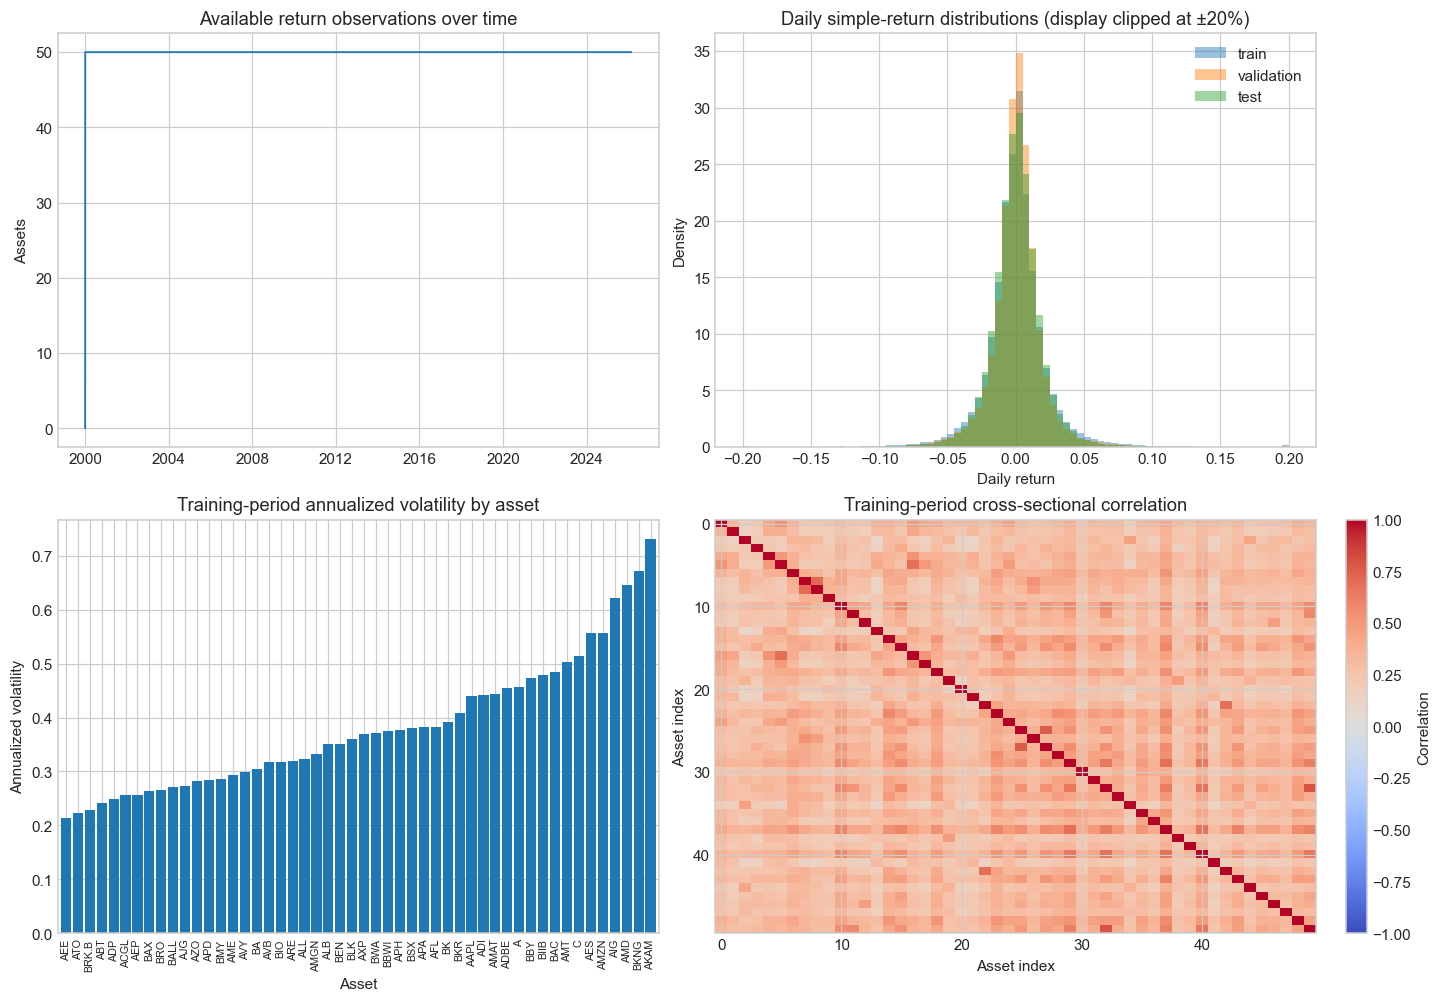

,pairwise_correlation
count,1225.000000
mean,0.319670
std,0.099332
min,0.111138
5%,0.181625
25%,0.249264
50%,0.307235
75%,0.374463
95%,0.504256
max,0.791104


A separate missingness heatmap is omitted because every split is a fully balanced date × asset panel; the availability plot conveys this more compactly.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

available_assets = simple_returns.notna().sum(axis=1)
axes[0, 0].plot(available_assets.index, available_assets, linewidth=1.2)
axes[0, 0].set(title="Available return observations over time", ylabel="Assets")

for split, split_return_frame in return_splits.items():
    values = split_return_frame.stack().clip(-0.20, 0.20)
    axes[0, 1].hist(values, bins=80, alpha=0.45, density=True, label=split)
axes[0, 1].set(
    title="Daily simple-return distributions (display clipped at ±20%)",
    xlabel="Daily return",
    ylabel="Density",
)
axes[0, 1].legend()

train_volatility = return_splits["train"].std() * np.sqrt(TRADING_DAYS)
train_volatility.sort_values().plot(kind="bar", ax=axes[1, 0], width=0.85)
axes[1, 0].set(
    title="Training-period annualized volatility by asset",
    xlabel="Asset",
    ylabel="Annualized volatility",
)
axes[1, 0].tick_params(axis="x", labelsize=7)

train_corr = return_splits["train"].corr()
image = axes[1, 1].imshow(train_corr, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
axes[1, 1].set(
    title="Training-period cross-sectional correlation",
    xlabel="Asset index",
    ylabel="Asset index",
)
fig.colorbar(image, ax=axes[1, 1], label="Correlation")
plt.show()

upper_triangle = train_corr.where(np.triu(np.ones(train_corr.shape), k=1).astype(bool)).stack()
display(
    upper_triangle.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .rename("pairwise_correlation")
    .to_frame()
)
print(
    "A separate missingness heatmap is omitted because every split is a fully balanced "
    "date × asset panel; the availability plot conveys this more compactly."
)

## 7. Investable Universe

An asset is eligible at formation date \(t\) only if, using dates strictly before \(t\):

1. it has at least the configured number of trailing simple returns;
2. trailing missingness does not exceed 5%;
3. its latest strictly prior price is finite and positive; and
4. the joint complete-case covariance sample remains sufficiently long.

There is no future-membership filter and no requirement that an asset survive to the test period. The balanced source panel means all 50 supplied securities are generally eligible, but the function is dynamic for future extensions.

In [9]:
def get_eligible_universe(
    returns: pd.DataFrame,
    prices: pd.DataFrame,
    formation_date: pd.Timestamp,
    config: BacktestConfig,
) -> tuple[list[str], pd.DataFrame]:
    """Select assets from trailing information strictly prior to formation."""
    history = returns.loc[returns.index < formation_date].tail(config.lookback)
    prior_prices = prices.loc[prices.index < formation_date]
    if history.empty or prior_prices.empty:
        raise ValueError(f"No strictly prior history for formation date {formation_date.date()}.")
    assert history.index.max() < formation_date

    observation_count = history.notna().sum()
    missing_fraction = history.isna().mean()
    last_price = prior_prices.iloc[-1]
    eligible_mask = (
        observation_count.ge(config.min_observations)
        & missing_fraction.le(config.max_missing_fraction)
        & last_price.notna()
        & last_price.gt(0)
    )
    eligible = sorted(observation_count.index[eligible_mask].tolist())
    if not eligible:
        raise ValueError(f"No eligible assets at {formation_date.date()}.")

    joint_history = history[eligible].dropna(how="any")
    if len(joint_history) < config.min_observations:
        raise ValueError(
            f"Only {len(joint_history)} joint observations at {formation_date.date()}, "
            f"below required {config.min_observations}."
        )
    return eligible, joint_history


example_config = CANDIDATE_CONFIGS[0]
eligibility_examples = []
for split in ("validation", "test"):
    formation_date = split_dates[split][0]
    eligible, history = get_eligible_universe(
        simple_returns, price_matrix, formation_date, example_config
    )
    eligibility_examples.append(
        {
            "split": split,
            "formation_date": formation_date,
            "history_end": history.index.max(),
            "eligible_assets": len(eligible),
            "joint_observations": len(history),
        }
    )
display(pd.DataFrame(eligibility_examples))

,split,formation_date,history_end,eligible_assets,joint_observations
0,validation,2017-01-03,2016-12-30,50,126
1,test,2021-01-04,2020-12-31,50,126


## 8. Validation Protocol

The candidate set is intentionally small: monthly rebalancing across 126-, 252-, and 504-day lookbacks and 10%, 15%, and 20% caps, plus one theoretically defensible quarterly anchor. Minimum observations equal 80% of the lookback. Configuration selection uses only net validation returns and a weighted rank score: realized volatility (30%), CVaR 95% (25%), maximum drawdown (20%), annualized turnover (10%), HHI concentration (10%), and Sharpe ratio (5%). Lower is better; Sharpe is reverse-ranked. Test data do not enter this score.

## 9. Portfolio Engine

In [10]:
def make_rebalance_dates(index: pd.DatetimeIndex, frequency: Literal["M", "Q"]) -> pd.DatetimeIndex:
    """Return the first observed trading date in each calendar month or quarter."""
    periods = index.to_period(frequency)
    return index[~periods.duplicated()]


def project_capped_simplex(values: np.ndarray, cap: float) -> np.ndarray:
    """Project numerical solver output onto sum-one long-only capped weights."""
    values = np.asarray(values, dtype=float)
    if len(values) * cap < 1 - 1e-12:
        raise ValueError("The weight cap is infeasible for the eligible universe.")
    lower = values.min() - cap
    upper = values.max()
    for _ in range(100):
        midpoint = (lower + upper) / 2
        projected = np.clip(values - midpoint, 0.0, cap)
        if projected.sum() > 1.0:
            lower = midpoint
        else:
            upper = midpoint
    projected = np.clip(values - (lower + upper) / 2, 0.0, cap)
    projected /= projected.sum()
    return projected


def equal_weight_weights(assets: list[str]) -> pd.Series:
    """Return equal weights for the current point-in-time universe."""
    if not assets:
        raise ValueError("Equal weighting requires at least one eligible asset.")
    return pd.Series(1.0 / len(assets), index=assets, dtype=float)


def estimate_covariance(
    history: pd.DataFrame, estimator: Literal["sample", "ledoit_wolf"]
) -> tuple[np.ndarray, dict[str, float]]:
    """Estimate sample or Ledoit–Wolf covariance and condition diagnostics."""
    values = history.to_numpy(dtype=float)
    sample_covariance = np.cov(values, rowvar=False, ddof=1)
    sample_condition = float(np.linalg.cond(sample_covariance))
    if estimator == "sample":
        covariance = sample_covariance
        shrinkage = np.nan
    elif estimator == "ledoit_wolf":
        fitted = LedoitWolf(assume_centered=False, store_precision=False).fit(values)
        covariance = fitted.covariance_
        shrinkage = float(fitted.shrinkage_)
    else:
        raise ValueError(f"Unknown covariance estimator: {estimator}")
    covariance = (covariance + covariance.T) / 2
    return covariance, {
        "shrinkage": shrinkage,
        "sample_condition_number": sample_condition,
        "covariance_condition_number": float(np.linalg.cond(covariance)),
    }


def solve_gmv(covariance: np.ndarray, assets: list[str], max_weight: float) -> tuple[pd.Series, dict]:
    """Solve the convex bounded-simplex GMV quadratic program with SLSQP."""
    n_assets = len(assets)
    if n_assets * max_weight < 1 - 1e-10:
        raise ValueError(
            f"Infeasible cap {max_weight:.3f} with only {n_assets} eligible assets."
        )
    variance_scale = float(np.median(np.diag(covariance)))
    if not np.isfinite(variance_scale) or variance_scale <= 0:
        raise ValueError("Covariance scaling requires a finite positive median variance.")
    # Positive scalar rescaling preserves the exact GMV minimizer while keeping
    # the SLSQP quadratic objective and internal Hessian numerically well scaled.
    scaled_covariance = covariance / variance_scale
    initial = np.full(n_assets, 1.0 / n_assets)
    # np.dot avoids spurious NumPy/Accelerate matmul warnings observed on some macOS
    # builds while producing the same finite quadratic form and gradient.
    objective = lambda weights: float(np.dot(np.dot(weights, scaled_covariance), weights))
    gradient = lambda weights: 2.0 * np.dot(scaled_covariance, weights)
    result = minimize(
        objective,
        x0=initial,
        jac=gradient,
        method="SLSQP",
        bounds=[(0.0, max_weight)] * n_assets,
        constraints={"type": "eq", "fun": lambda weights: weights.sum() - 1.0,
                     "jac": lambda weights: np.ones_like(weights)},
        options={"ftol": 1e-12, "maxiter": 1_000, "disp": False},
    )
    feasible = (
        result.success
        and abs(result.x.sum() - 1.0) <= 1e-7
        and result.x.min() >= -1e-8
        and result.x.max() <= max_weight + 1e-8
    )
    fallback_used = not feasible
    if feasible:
        weights = project_capped_simplex(result.x, max_weight)
    else:
        # Documented fallback: feasible equal weights on the same eligible universe.
        weights = equal_weight_weights(assets).to_numpy()
        if weights.max() > max_weight + 1e-12:
            raise RuntimeError(
                f"GMV solver failed and equal-weight fallback violates the cap: {result.message}"
            )
    return pd.Series(weights, index=assets), {
        "solver_success": bool(feasible),
        "fallback_used": bool(fallback_used),
        "solver_message": str(result.message),
        "objective_value": float(np.dot(np.dot(weights, covariance), weights)),
        "covariance_scale": variance_scale,
        "iterations": int(getattr(result, "nit", -1)),
    }


def drift_weights(weights: pd.Series, realized_returns: pd.Series) -> pd.Series:
    """Drift closing weights after realized simple returns."""
    gross_return = float(weights.dot(realized_returns))
    denominator = 1.0 + gross_return
    if denominator <= 0:
        raise RuntimeError("Portfolio wealth became non-positive during weight drift.")
    drifted = weights.mul(1.0 + realized_returns).div(denominator)
    return drifted / drifted.sum()

### 9.1 1/N Portfolio

Every eligible security receives \(1/N_t\). The universe and rebalance dates are identical to GMV. The cap is not itself an equal-weight rule, but the supplied panel is large enough that 1/N remains below every candidate GMV cap.

### 9.2 Sample GMV (Diagnostic)

The diagnostic substitutes the ordinary sample covariance for \(\widehat\Sigma_{LW}\) while retaining identical constraints and timing.

### 9.3 Ledoit–Wolf Shrinkage GMV

Ledoit–Wolf shrinkage regularizes the covariance matrix toward a structured target. Solver success and fallback use are recorded at every formation date; a feasible equal-weight allocation on the same universe is the explicit fallback.

In [11]:
Strategy = Literal["equal_weight", "sample_gmv", "shrinkage_gmv"]


def run_walk_forward_backtest(
    all_returns: pd.DataFrame,
    all_prices: pd.DataFrame,
    evaluation_dates: pd.DatetimeIndex,
    config: BacktestConfig,
    strategy: Strategy,
) -> BacktestResult:
    """Run a strict point-in-time backtest with drift-aware turnover and costs."""
    evaluation_dates = pd.DatetimeIndex(evaluation_dates).sort_values().unique()
    if len(evaluation_dates) == 0:
        raise ValueError("Evaluation dates cannot be empty.")
    rebalance_dates = set(make_rebalance_dates(evaluation_dates, config.rebalance))
    pre_trade_weights = pd.Series(dtype=float)
    current_weights = pd.Series(dtype=float)
    daily_records: list[dict] = []
    weight_records: list[pd.Series] = []
    diagnostic_records: list[dict] = []

    for date in evaluation_dates:
        transaction_cost = 0.0
        turnover = 0.0
        if date in rebalance_dates:
            eligible_assets, estimation_history = get_eligible_universe(
                all_returns, all_prices, date, config
            )
            assert estimation_history.index.max() < date, "Look-ahead detected in estimation history."

            covariance_diagnostics = {
                "shrinkage": np.nan,
                "sample_condition_number": np.nan,
                "covariance_condition_number": np.nan,
            }
            solver_diagnostics = {
                "solver_success": True,
                "fallback_used": False,
                "solver_message": "not applicable",
                "objective_value": np.nan,
                "iterations": 0,
            }

            if strategy == "equal_weight":
                target_weights = equal_weight_weights(eligible_assets)
            else:
                estimator = "sample" if strategy == "sample_gmv" else "ledoit_wolf"
                covariance, covariance_diagnostics = estimate_covariance(
                    estimation_history, estimator
                )
                target_weights, solver_diagnostics = solve_gmv(
                    covariance, eligible_assets, config.max_weight
                )

            union = pre_trade_weights.index.union(target_weights.index)
            aligned_pre_trade = pre_trade_weights.reindex(union, fill_value=0.0)
            aligned_target = target_weights.reindex(union, fill_value=0.0)
            turnover = float((aligned_target - aligned_pre_trade).abs().sum())
            transaction_cost = config.cost_rate * turnover
            current_weights = target_weights.copy()

            full_target = target_weights.reindex(all_returns.columns, fill_value=0.0)
            full_target.name = date
            weight_records.append(full_target)
            diagnostic_records.append(
                {
                    "rebalance_date": date,
                    "history_start": estimation_history.index.min(),
                    "history_end": estimation_history.index.max(),
                    "history_observations": len(estimation_history),
                    "eligible_assets": len(eligible_assets),
                    "turnover": turnover,
                    "transaction_cost": transaction_cost,
                    "active_positions": int(target_weights.gt(1e-8).sum()),
                    "maximum_weight": float(target_weights.max()),
                    "hhi": float(target_weights.pow(2).sum()),
                    "effective_assets": float(1.0 / target_weights.pow(2).sum()),
                    "weights_at_cap": int(
                        np.isclose(target_weights, config.max_weight, atol=1e-5).sum()
                    ),
                    **covariance_diagnostics,
                    **solver_diagnostics,
                }
            )

        realized = all_returns.loc[date, current_weights.index]
        if realized.isna().any():
            missing_assets = realized.index[realized.isna()].tolist()
            raise ValueError(
                f"Missing realized returns for held assets at {date.date()}: {missing_assets}"
            )
        gross_return = float(current_weights.dot(realized))
        net_return = gross_return - transaction_cost
        if net_return <= -1:
            raise RuntimeError(f"Net portfolio loss reached -100% at {date.date()}.")
        daily_records.append(
            {
                "date": date,
                "gross_return": gross_return,
                "net_return": net_return,
                "transaction_cost": transaction_cost,
                "turnover": turnover,
            }
        )
        pre_trade_weights = drift_weights(current_weights, realized)

    returns_frame = pd.DataFrame(daily_records).set_index("date")
    target_weights_frame = pd.DataFrame(weight_records).fillna(0.0)
    target_weights_frame.index.name = "rebalance_date"
    diagnostics_frame = pd.DataFrame(diagnostic_records).set_index("rebalance_date")

    if not (diagnostics_frame["history_end"] < diagnostics_frame.index).all():
        raise AssertionError("At least one portfolio used non-prior estimation data.")
    return BacktestResult(
        strategy=strategy,
        config=config,
        returns=returns_frame,
        target_weights=target_weights_frame,
        diagnostics=diagnostics_frame,
    )

## 10. Validation-Period Model Selection

In [12]:
def drawdown_series(returns: pd.Series) -> pd.Series:
    """Return the path of percentage drawdowns from prior wealth peaks."""
    wealth = (1.0 + returns.dropna()).cumprod()
    return wealth / wealth.cummax() - 1.0


def empirical_var_cvar(returns: pd.Series, alpha: float = 0.95) -> tuple[float, float]:
    """Estimate VaR and CVaR as positive loss-distribution tail quantities."""
    losses = -returns.dropna().to_numpy(dtype=float)
    var = float(np.quantile(losses, alpha))
    tail = losses[losses >= var]
    cvar = float(tail.mean()) if len(tail) else var
    return var, cvar


def longest_drawdown_duration(returns: pd.Series) -> int:
    """Return the longest number of consecutive observations below a wealth peak."""
    underwater = drawdown_series(returns).lt(0)
    groups = underwater.ne(underwater.shift(fill_value=False)).cumsum()
    runs = underwater.groupby(groups).sum()
    return int(runs.max()) if len(runs) else 0


def calculate_performance_metrics(
    result: BacktestResult, return_column: Literal["gross_return", "net_return"] = "net_return"
) -> pd.Series:
    """Calculate return, risk, tail, risk-adjusted, and implementation metrics."""
    returns = result.returns[return_column].dropna()
    n_obs = len(returns)
    wealth = float((1.0 + returns).prod())
    years = n_obs / TRADING_DAYS
    cagr = wealth ** (1.0 / years) - 1.0 if years > 0 and wealth > 0 else np.nan
    volatility = float(returns.std(ddof=1) * np.sqrt(TRADING_DAYS))
    downside = float(np.sqrt(np.mean(np.minimum(returns, 0.0) ** 2)) * np.sqrt(TRADING_DAYS))
    mean_daily = float(returns.mean())
    sharpe = float(mean_daily / returns.std(ddof=1) * np.sqrt(TRADING_DAYS)) if returns.std(ddof=1) > 0 else np.nan
    sortino = float(mean_daily * TRADING_DAYS / downside) if downside > 0 else np.nan
    max_drawdown = float(-drawdown_series(returns).min())
    var_95, cvar_95 = empirical_var_cvar(returns, 0.95)
    var_99, cvar_99 = empirical_var_cvar(returns, 0.99)
    diagnostics = result.diagnostics
    target_change = result.target_weights.diff().abs().sum(axis=1).iloc[1:]
    return pd.Series(
        {
            "Cumulative Return": wealth - 1.0,
            "CAGR": cagr,
            "Average Daily Return": mean_daily,
            "Arithmetic Annual Return": mean_daily * TRADING_DAYS,
            "Annualized Volatility": volatility,
            "Downside Deviation": downside,
            "Maximum Drawdown": max_drawdown,
            "Drawdown Duration": longest_drawdown_duration(returns),
            "VaR 95%": var_95,
            "CVaR 95%": cvar_95,
            "VaR 99%": var_99,
            "CVaR 99%": cvar_99,
            "Sharpe": sharpe,
            "Sortino": sortino,
            "Calmar": cagr / max_drawdown if max_drawdown > 0 else np.nan,
            "Average Turnover": float(diagnostics["turnover"].mean()),
            "Annualized Turnover": float(diagnostics["turnover"].sum() / years),
            "Total Transaction Costs": float(result.returns["transaction_cost"].sum()),
            "Rebalances": len(diagnostics),
            "Average Active Positions": float(diagnostics["active_positions"].mean()),
            "Average Maximum Weight": float(diagnostics["maximum_weight"].mean()),
            "Average HHI": float(diagnostics["hhi"].mean()),
            "Average Effective Assets": float(diagnostics["effective_assets"].mean()),
            "Mean Target L1 Change": float(target_change.mean()) if len(target_change) else np.nan,
            "Solver Failures": int(diagnostics["fallback_used"].sum()),
        }
    )


def compact_metric_table(metrics: pd.DataFrame) -> pd.io.formats.style.Styler:
    """Apply publication-readable formatting to a strategy-by-metric table."""
    percent_columns = [
        "Cumulative Return", "CAGR", "Average Daily Return", "Arithmetic Annual Return",
        "Annualized Volatility", "Downside Deviation", "Maximum Drawdown", "VaR 95%",
        "CVaR 95%", "VaR 99%", "CVaR 99%", "Total Transaction Costs",
        "Average Maximum Weight", "Average HHI",
    ]
    formats = {column: "{:.2%}" for column in percent_columns if column in metrics.columns}
    formats.update(
        {column: "{:.3f}" for column in ["Sharpe", "Sortino", "Calmar"] if column in metrics.columns}
    )
    formats.update(
        {column: "{:.2f}" for column in ["Average Turnover", "Annualized Turnover", "Average Effective Assets"] if column in metrics.columns}
    )
    return metrics.style.format(formats, na_rep="—")

In [13]:
validation_grid_results: dict[str, BacktestResult] = {}
validation_grid_rows: list[dict] = []

for candidate in CANDIDATE_CONFIGS:
    candidate_result = run_walk_forward_backtest(
        simple_returns,
        price_matrix,
        split_dates["validation"],
        candidate,
        strategy="shrinkage_gmv",
    )
    validation_grid_results[candidate.label] = candidate_result
    metrics = calculate_performance_metrics(candidate_result, "net_return")
    validation_grid_rows.append({"config": candidate.label, **asdict(candidate), **metrics.to_dict()})

validation_grid = pd.DataFrame(validation_grid_rows).set_index("config")
score_components = pd.DataFrame(index=validation_grid.index)
score_components["volatility_rank"] = validation_grid["Annualized Volatility"].rank(method="average")
score_components["cvar_rank"] = validation_grid["CVaR 95%"].rank(method="average")
score_components["drawdown_rank"] = validation_grid["Maximum Drawdown"].rank(method="average")
score_components["turnover_rank"] = validation_grid["Annualized Turnover"].rank(method="average")
score_components["concentration_rank"] = validation_grid["Average HHI"].rank(method="average")
score_components["sharpe_rank"] = validation_grid["Sharpe"].rank(method="average", ascending=False)
validation_grid["Risk-Focused Score"] = (
    0.30 * score_components["volatility_rank"]
    + 0.25 * score_components["cvar_rank"]
    + 0.20 * score_components["drawdown_rank"]
    + 0.10 * score_components["turnover_rank"]
    + 0.10 * score_components["concentration_rank"]
    + 0.05 * score_components["sharpe_rank"]
)

selected_label = validation_grid["Risk-Focused Score"].idxmin()
FROZEN_CONFIG = next(config for config in CANDIDATE_CONFIGS if config.label == selected_label)
CONFIG_SELECTION_SOURCE = "validation"

selection_columns = [
    "lookback", "rebalance", "max_weight", "min_observations",
    "Annualized Volatility", "CVaR 95%", "Maximum Drawdown", "Sharpe",
    "Annualized Turnover", "Average HHI", "Risk-Focused Score", "Solver Failures",
]
validation_selection_table = validation_grid[selection_columns].sort_values("Risk-Focused Score")
display(
    validation_selection_table.style.format(
        {
            "max_weight": "{:.0%}", "Annualized Volatility": "{:.2%}",
            "CVaR 95%": "{:.2%}", "Maximum Drawdown": "{:.2%}",
            "Sharpe": "{:.3f}", "Annualized Turnover": "{:.2f}",
            "Average HHI": "{:.3f}", "Risk-Focused Score": "{:.2f}",
        }
    ).background_gradient(subset=["Risk-Focused Score"], cmap="Greens_r")
)
print(f"Frozen after validation: {FROZEN_CONFIG}")

,lookback,rebalance,max_weight,min_observations,Annualized Volatility,CVaR 95%,Maximum Drawdown,Sharpe,Annualized Turnover,Average HHI,Risk-Focused Score,Solver Failures
config,,,,,,,,,,,,
LB252_M_CAP15,252,M,15%,202,18.40%,2.82%,33.66%,0.891,3.23,0.083,2.30,0.000000
LB126_M_CAP10,126,M,10%,101,18.39%,2.86%,34.03%,0.857,4.51,0.068,3.35,0.000000
LB252_M_CAP10,252,M,10%,202,18.42%,2.83%,34.44%,0.883,2.84,0.070,3.45,0.000000
LB252_M_CAP20,252,M,20%,202,18.52%,2.84%,33.67%,0.886,3.36,0.093,4.35,0.000000
LB126_M_CAP15,126,M,15%,101,18.53%,2.87%,34.11%,0.857,5.02,0.080,5.75,0.000000
LB126_M_CAP20,126,M,20%,101,18.51%,2.87%,34.14%,0.869,5.20,0.089,5.95,0.000000
LB504_M_CAP20,504,M,20%,404,18.67%,2.85%,36.11%,0.702,2.22,0.096,6.60,0.000000
LB252_Q_CAP15,252,Q,15%,202,18.93%,2.91%,35.27%,0.864,2.10,0.082,7.60,0.000000
LB504_M_CAP15,504,M,15%,404,18.79%,2.87%,36.17%,0.715,2.21,0.084,7.65,0.000000


Frozen after validation: BacktestConfig(lookback=252, rebalance='M', max_weight=0.15, min_observations=202, max_missing_fraction=0.05, transaction_cost_bps=10.0)


## 11. Frozen Test-Period Backtest

In [14]:
STRATEGY_LABELS = {
    "equal_weight": "1/N",
    "shrinkage_gmv": "Shrinkage GMV",
    "sample_gmv": "Sample GMV (Diagnostic)",
}

validation_results = {
    strategy: run_walk_forward_backtest(
        simple_returns, price_matrix, split_dates["validation"], FROZEN_CONFIG, strategy
    )
    for strategy in STRATEGY_LABELS
}

# The configuration is frozen above; only now is the test walk-forward executed.
assert CONFIG_SELECTION_SOURCE == "validation"
test_results = {
    strategy: run_walk_forward_backtest(
        simple_returns, price_matrix, split_dates["test"], FROZEN_CONFIG, strategy
    )
    for strategy in STRATEGY_LABELS
}

for period, results in {"validation": validation_results, "test": test_results}.items():
    failures = {
        STRATEGY_LABELS[strategy]: int(result.diagnostics["fallback_used"].sum())
        for strategy, result in results.items()
    }
    print(f"{period.title()} solver fallback counts: {failures}")

Validation solver fallback counts: {'1/N': 0, 'Shrinkage GMV': 0, 'Sample GMV (Diagnostic)': 0}
Test solver fallback counts: {'1/N': 0, 'Shrinkage GMV': 0, 'Sample GMV (Diagnostic)': 0}


## 12. Performance Metrics

In [15]:
PRIMARY_COLUMNS = [
    "CAGR", "Annualized Volatility", "Sharpe", "Sortino", "Maximum Drawdown",
    "VaR 95%", "CVaR 95%", "Average Turnover", "Annualized Turnover",
    "Total Transaction Costs", "Average Effective Assets",
]


def strategy_metric_frame(
    results: dict[str, BacktestResult], return_column: Literal["gross_return", "net_return"]
) -> pd.DataFrame:
    """Create a strategy-by-metric comparison frame."""
    return pd.DataFrame(
        {
            STRATEGY_LABELS[strategy]: calculate_performance_metrics(result, return_column)
            for strategy, result in results.items()
        }
    ).T


validation_metrics_net = strategy_metric_frame(validation_results, "net_return")
test_metrics_net = strategy_metric_frame(test_results, "net_return")
test_metrics_gross = strategy_metric_frame(test_results, "gross_return")

print("Validation period — net of transaction costs")
display(compact_metric_table(validation_metrics_net[PRIMARY_COLUMNS]))
print("Final test period — net of transaction costs (primary scientific comparison)")
display(compact_metric_table(test_metrics_net[PRIMARY_COLUMNS]))

gross_net_test = pd.concat(
    {"Gross": test_metrics_gross[["CAGR", "Annualized Volatility", "Sharpe"]],
     "Net": test_metrics_net[["CAGR", "Annualized Volatility", "Sharpe"]]},
    axis=1,
)
print("Final test period — gross versus net")
display(gross_net_test.style.format("{:.2%}", subset=pd.IndexSlice[:, pd.IndexSlice[:, ["CAGR", "Annualized Volatility"]]]).format("{:.3f}", subset=pd.IndexSlice[:, pd.IndexSlice[:, ["Sharpe"]]]))

Validation period — net of transaction costs


,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,VaR 95%,CVaR 95%,Average Turnover,Annualized Turnover,Total Transaction Costs,Average Effective Assets
1/N,18.70%,22.17%,0.885,1.222,38.70%,2.03%,3.52%,0.03,0.36,0.15%,50.00
Shrinkage GMV,15.83%,18.40%,0.891,1.237,33.66%,1.29%,2.82%,0.27,3.23,1.29%,12.99
Sample GMV (Diagnostic),16.08%,18.42%,0.903,1.255,33.45%,1.28%,2.82%,0.30,3.58,1.43%,11.25


Final test period — net of transaction costs (primary scientific comparison)


,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,VaR 95%,CVaR 95%,Average Turnover,Annualized Turnover,Total Transaction Costs,Average Effective Assets
1/N,12.47%,16.92%,0.779,1.128,20.67%,1.66%,2.41%,0.03,0.31,0.16%,50.00
Shrinkage GMV,9.29%,13.21%,0.739,1.054,18.67%,1.30%,1.86%,0.26,3.17,1.62%,12.41
Sample GMV (Diagnostic),9.40%,13.23%,0.745,1.063,18.93%,1.30%,1.87%,0.28,3.39,1.73%,10.88


Final test period — gross versus net


In [16]:
def worst_drawdown_episodes(returns: pd.Series, top_n: int = 5) -> pd.DataFrame:
    """Identify the deepest completed or ongoing drawdown episodes."""
    drawdowns = drawdown_series(returns)
    episodes = []
    start = None
    for date, value in drawdowns.items():
        if value < 0 and start is None:
            start = date
        if value == 0 and start is not None:
            segment = drawdowns.loc[start:date]
            episodes.append(
                {
                    "start": start,
                    "trough": segment.idxmin(),
                    "recovery": date,
                    "depth": -float(segment.min()),
                    "duration_observations": len(segment) - 1,
                }
            )
            start = None
    if start is not None:
        segment = drawdowns.loc[start:]
        episodes.append(
            {
                "start": start,
                "trough": segment.idxmin(),
                "recovery": pd.NaT,
                "depth": -float(segment.min()),
                "duration_observations": len(segment),
            }
        )
    return pd.DataFrame(episodes).sort_values("depth", ascending=False).head(top_n)


drawdown_episode_table = pd.concat(
    {
        STRATEGY_LABELS[strategy]: worst_drawdown_episodes(result.returns["net_return"])
        for strategy, result in test_results.items()
    },
    names=["strategy", "episode"],
)
print("Worst final-test drawdown episodes (positive depth magnitudes)")
display(drawdown_episode_table.style.format({"depth": "{:.2%}"}))

Worst final-test drawdown episodes (positive depth magnitudes)


## 13. CVaR and Tail-Risk Analysis

For daily loss \(L_t=-R_t\), empirical VaR 95% is the 95th percentile of losses and CVaR 95% is the mean loss conditional on \(L_t\geq VaR_{0.95}\). Both are reported as positive daily loss quantities. They are evaluation metrics; neither is optimized directly.

,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%
1/N,1.66%,2.41%,2.89%,3.78%
Shrinkage GMV,1.30%,1.86%,2.10%,2.89%
Sample GMV (Diagnostic),1.30%,1.87%,2.07%,2.90%


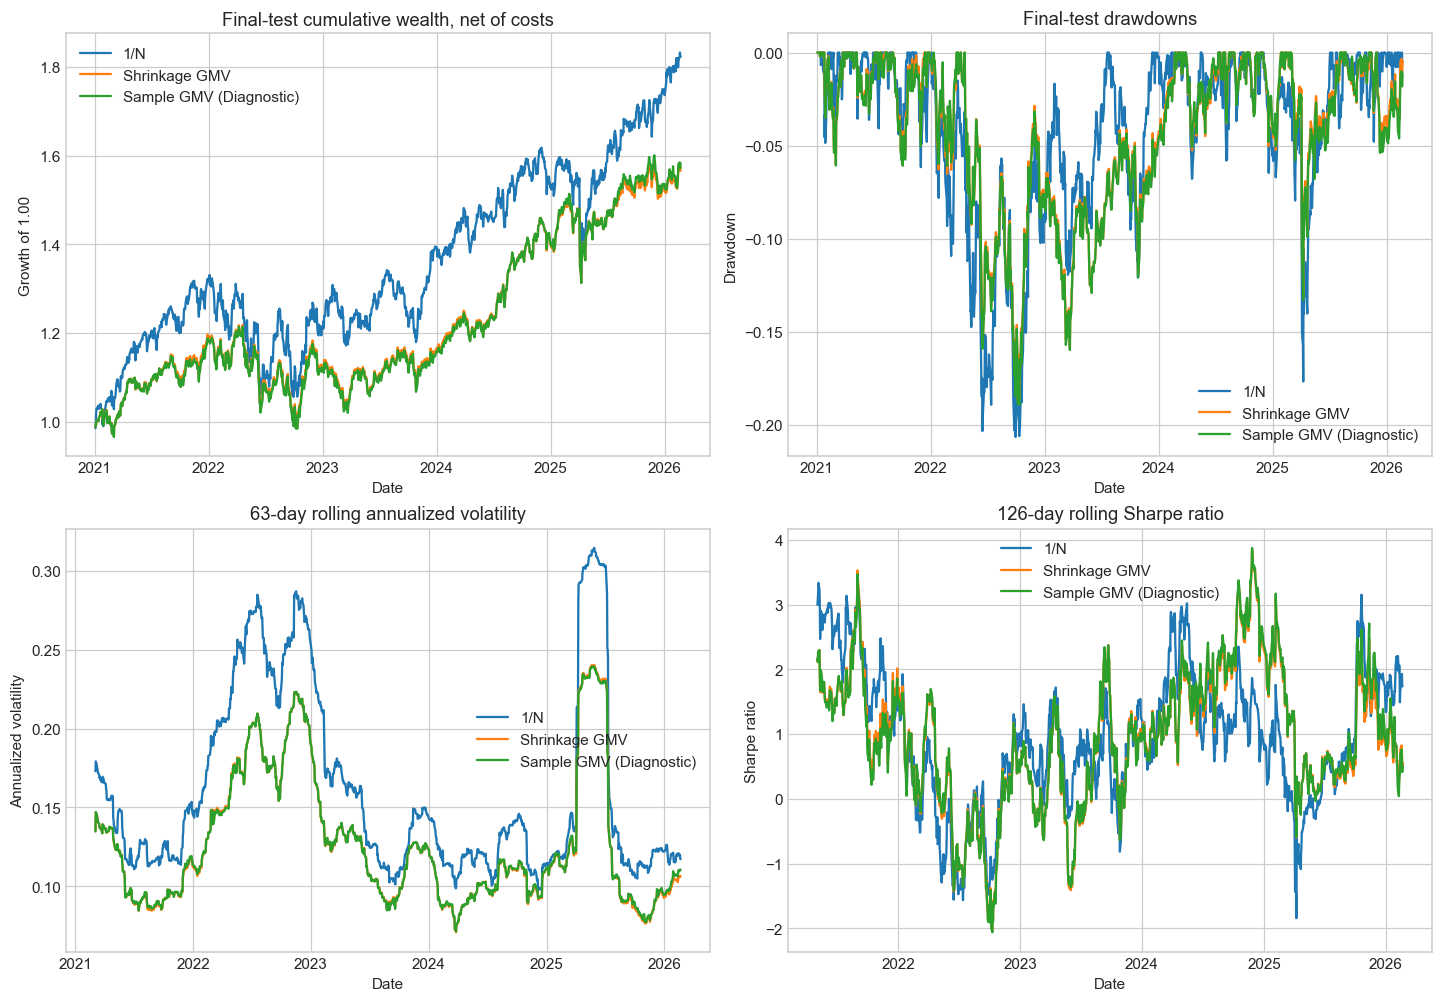

In [17]:
tail_risk_table = test_metrics_net[["VaR 95%", "CVaR 95%", "VaR 99%", "CVaR 99%"]]
display(tail_risk_table.style.format("{:.2%}"))

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for strategy, result in test_results.items():
    label = STRATEGY_LABELS[strategy]
    wealth = (1.0 + result.returns["net_return"]).cumprod()
    axes[0, 0].plot(wealth.index, wealth, label=label)
    axes[0, 1].plot(
        result.returns.index,
        drawdown_series(result.returns["net_return"]),
        label=label,
    )
    rolling_volatility = result.returns["net_return"].rolling(63, min_periods=42).std() * np.sqrt(TRADING_DAYS)
    axes[1, 0].plot(rolling_volatility.index, rolling_volatility, label=label)
    rolling_mean = result.returns["net_return"].rolling(126, min_periods=84).mean()
    rolling_std = result.returns["net_return"].rolling(126, min_periods=84).std()
    rolling_sharpe = rolling_mean.div(rolling_std).mul(np.sqrt(TRADING_DAYS))
    axes[1, 1].plot(rolling_sharpe.index, rolling_sharpe, label=label)

axes[0, 0].set(title="Final-test cumulative wealth, net of costs", ylabel="Growth of 1.00")
axes[0, 1].set(title="Final-test drawdowns", ylabel="Drawdown")
axes[1, 0].set(title="63-day rolling annualized volatility", ylabel="Annualized volatility")
axes[1, 1].set(title="126-day rolling Sharpe ratio", ylabel="Sharpe ratio")
for axis in axes.flat:
    axis.set_xlabel("Date")
    axis.legend()
plt.show()

## 14. Portfolio Stability and Turnover

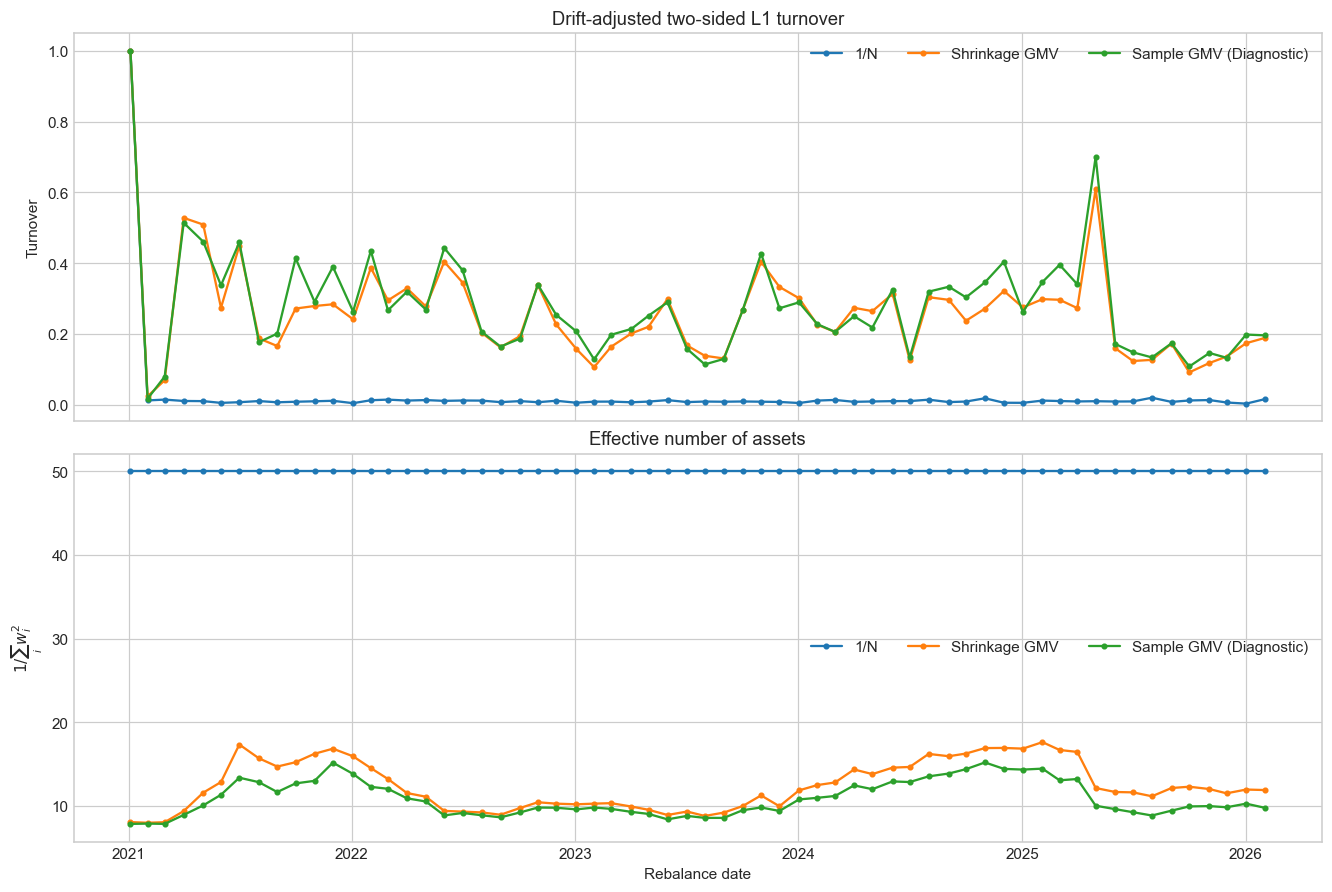

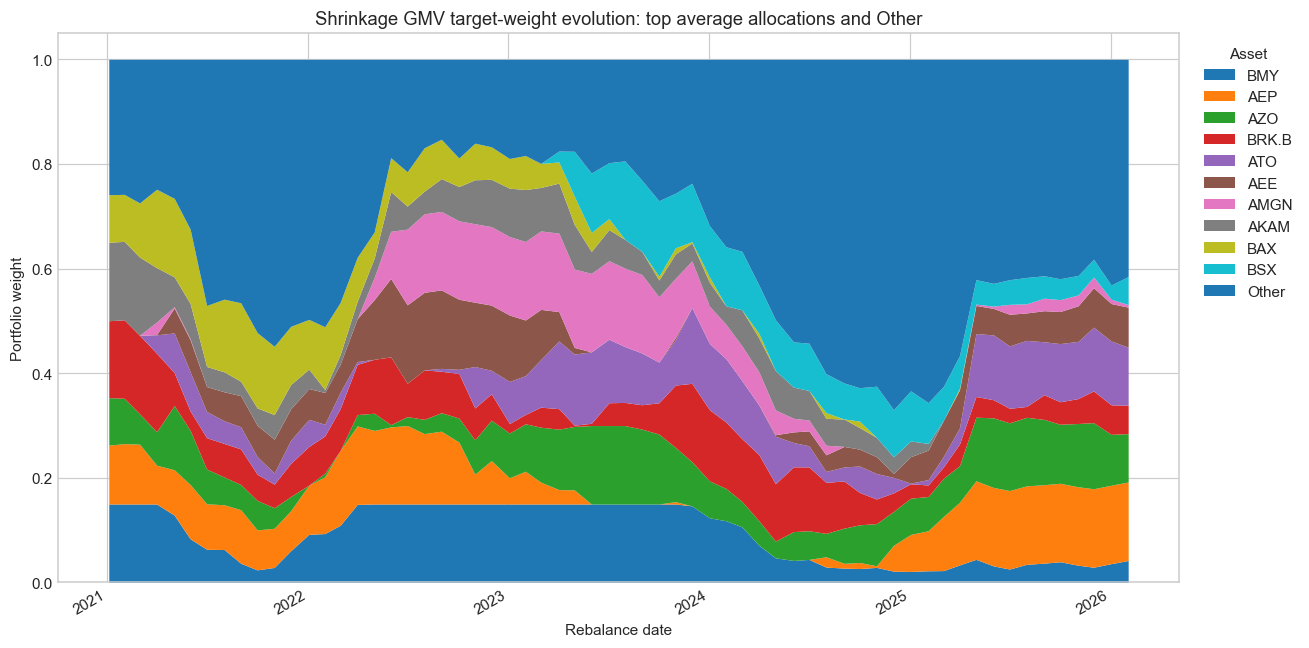

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
for strategy, result in test_results.items():
    label = STRATEGY_LABELS[strategy]
    axes[0].plot(result.diagnostics.index, result.diagnostics["turnover"], marker="o", ms=3, label=label)
    axes[1].plot(result.diagnostics.index, result.diagnostics["effective_assets"], marker="o", ms=3, label=label)
axes[0].set(title="Drift-adjusted two-sided L1 turnover", ylabel="Turnover")
axes[1].set(title="Effective number of assets", ylabel=r"$1/\sum_i w_i^2$", xlabel="Rebalance date")
for axis in axes:
    axis.legend(ncol=3)
plt.show()

shrinkage_weights = test_results["shrinkage_gmv"].target_weights
top_assets = shrinkage_weights.mean().nlargest(10).index
weight_plot = shrinkage_weights[top_assets].copy()
weight_plot["Other"] = 1.0 - weight_plot.sum(axis=1)
weight_plot.plot.area(figsize=(12, 6), linewidth=0)
plt.title("Shrinkage GMV target-weight evolution: top average allocations and Other")
plt.xlabel("Rebalance date")
plt.ylabel("Portfolio weight")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), title="Asset")
plt.tight_layout()
plt.show()

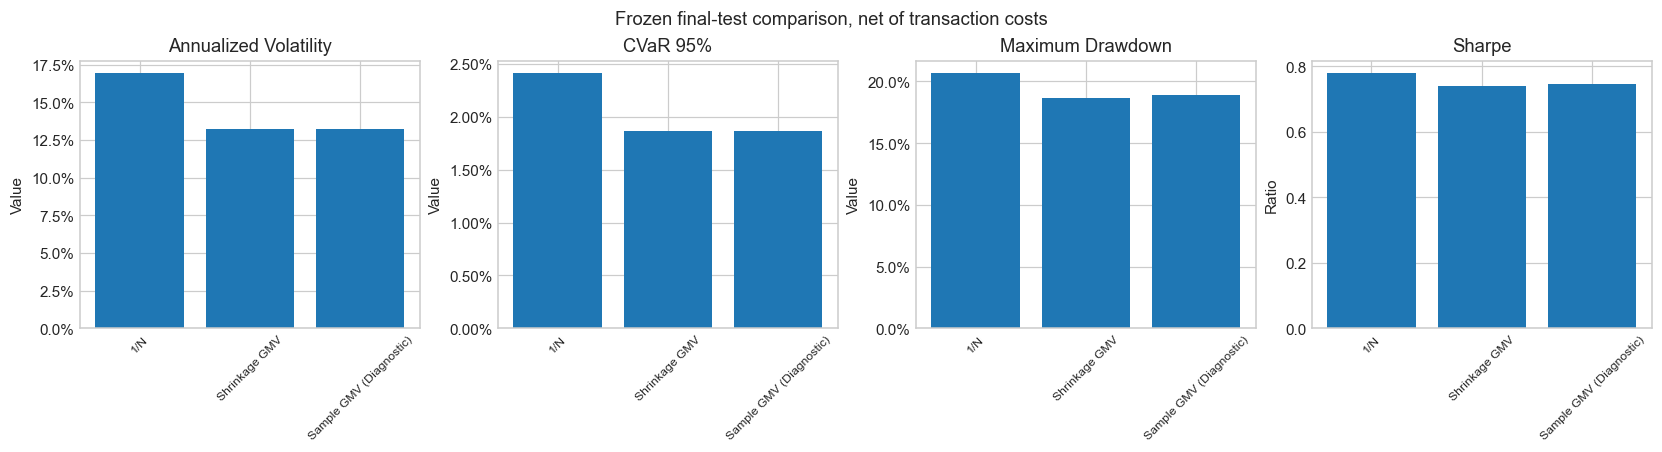

In [19]:
key_metrics = ["Annualized Volatility", "CVaR 95%", "Maximum Drawdown", "Sharpe"]
fig, axes = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
for axis, metric in zip(axes, key_metrics):
    values = test_metrics_net[metric]
    axis.bar(values.index, values.values)
    axis.set_title(metric)
    axis.tick_params(axis="x", rotation=45, labelsize=8)
    if metric != "Sharpe":
        axis.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    axis.set_ylabel("Ratio" if metric == "Sharpe" else "Value")
fig.suptitle("Frozen final-test comparison, net of transaction costs")
plt.show()

## 15. Statistical Uncertainty

In [20]:
def core_metrics_from_array(values: np.ndarray) -> dict[str, float]:
    """Compute bootstrap-ready path metrics from an ordered return sample."""
    series = pd.Series(values)
    wealth = float(np.prod(1.0 + values))
    years = len(values) / TRADING_DAYS
    cagr = wealth ** (1.0 / years) - 1.0 if wealth > 0 else np.nan
    std = float(series.std(ddof=1))
    _, cvar = empirical_var_cvar(series, 0.95)
    return {
        "CAGR": cagr,
        "Annualized Volatility": std * np.sqrt(TRADING_DAYS),
        "Sharpe": float(series.mean() / std * np.sqrt(TRADING_DAYS)) if std > 0 else np.nan,
        "CVaR 95%": cvar,
        "Maximum Drawdown": float(-drawdown_series(series).min()),
    }


def moving_block_bootstrap(
    paired_returns: pd.DataFrame,
    n_bootstrap: int = 1_000,
    block_length: int = 21,
    seed: int = SEED,
) -> dict[str, pd.DataFrame]:
    """Bootstrap paired strategy paths with shared moving-block draws."""
    data = paired_returns.dropna().to_numpy(dtype=float)
    n_obs, n_strategies = data.shape
    if n_obs < 2 * block_length:
        raise ValueError("The evaluation period is too short for the requested block length.")
    rng = np.random.default_rng(seed)
    strategy_draws = {column: [] for column in paired_returns.columns}
    paired_draws = []
    for _ in range(n_bootstrap):
        starts = rng.integers(0, n_obs - block_length + 1, size=int(np.ceil(n_obs / block_length)))
        indices = np.concatenate([np.arange(start, start + block_length) for start in starts])[:n_obs]
        sample = data[indices]
        sample_metrics = []
        for position, column in enumerate(paired_returns.columns):
            metrics = core_metrics_from_array(sample[:, position])
            strategy_draws[column].append(metrics)
            sample_metrics.append(metrics)
        paired_draws.append(
            {
                metric: sample_metrics[1][metric] - sample_metrics[0][metric]
                for metric in sample_metrics[0]
            }
        )
    return {
        **{column: pd.DataFrame(draws) for column, draws in strategy_draws.items()},
        "paired_difference": pd.DataFrame(paired_draws),
    }


paired_test_returns = pd.DataFrame(
    {
        "1/N": test_results["equal_weight"].returns["net_return"],
        "Shrinkage GMV": test_results["shrinkage_gmv"].returns["net_return"],
    }
)
bootstrap_draws = moving_block_bootstrap(paired_test_returns)

ci_rows = []
for strategy in ("1/N", "Shrinkage GMV"):
    estimates = core_metrics_from_array(paired_test_returns[strategy].to_numpy())
    for metric, estimate in estimates.items():
        lower, upper = bootstrap_draws[strategy][metric].quantile([0.025, 0.975])
        ci_rows.append(
            {"strategy": strategy, "metric": metric, "estimate": estimate, "lower_95": lower, "upper_95": upper}
        )
bootstrap_ci_table = pd.DataFrame(ci_rows).set_index(["strategy", "metric"])
display(bootstrap_ci_table.style.format("{:.3f}"))

improvement_direction = {
    "CAGR": "higher", "Annualized Volatility": "lower", "Sharpe": "higher",
    "CVaR 95%": "lower", "Maximum Drawdown": "lower",
}
paired_rows = []
point_difference = (
    pd.Series(core_metrics_from_array(paired_test_returns["Shrinkage GMV"].to_numpy()))
    - pd.Series(core_metrics_from_array(paired_test_returns["1/N"].to_numpy()))
)
for metric, direction in improvement_direction.items():
    draws = bootstrap_draws["paired_difference"][metric]
    lower, upper = draws.quantile([0.025, 0.975])
    probability_improvement = float((draws > 0).mean()) if direction == "higher" else float((draws < 0).mean())
    paired_rows.append(
        {
            "metric": metric,
            "Shrinkage GMV minus 1/N": point_difference[metric],
            "lower_95": lower,
            "upper_95": upper,
            "probability_of_improvement": probability_improvement,
            "preferred_direction": direction,
        }
    )
paired_uncertainty = pd.DataFrame(paired_rows).set_index("metric")
display(paired_uncertainty.style.format({
    "Shrinkage GMV minus 1/N": "{:.3f}", "lower_95": "{:.3f}",
    "upper_95": "{:.3f}", "probability_of_improvement": "{:.1%}",
}))
print(
    "Intervals use 1,000 paired moving-block resamples with 21-trading-day blocks. "
    "They quantify sampling uncertainty under serial dependence; they are not causal tests."
)

,Shrinkage GMV minus 1/N,lower_95,upper_95,probability_of_improvement,preferred_direction
metric,,,,,
CAGR,-0.032,-0.125,0.056,24.5%,higher
Annualized Volatility,-0.037,-0.045,-0.028,100.0%,lower
Sharpe,-0.040,-0.548,0.476,43.2%,higher
CVaR 95%,-0.006,-0.007,-0.004,100.0%,lower
Maximum Drawdown,-0.020,-0.135,0.065,77.6%,lower


Intervals use 1,000 paired moving-block resamples with 21-trading-day blocks. They quantify sampling uncertainty under serial dependence; they are not causal tests.


## 16. Robustness Checks and GMV Diagnostics

Validation-only robustness grid


,lookback,max_weight,Annualized Volatility,CVaR 95%,Maximum Drawdown,Annualized Turnover,Average HHI,Sharpe
config,,,,,,,,
LB126_M_CAP10,126,10%,18.39%,2.86%,34.03%,4.51,0.068,0.857
LB126_M_CAP15,126,15%,18.53%,2.87%,34.11%,5.02,0.080,0.857
LB126_M_CAP20,126,20%,18.51%,2.87%,34.14%,5.20,0.089,0.869
LB252_M_CAP10,252,10%,18.42%,2.83%,34.44%,2.84,0.070,0.883
LB252_M_CAP15,252,15%,18.40%,2.82%,33.66%,3.23,0.083,0.891
LB252_M_CAP20,252,20%,18.52%,2.84%,33.67%,3.36,0.093,0.886
LB504_M_CAP10,504,10%,18.90%,2.91%,36.83%,1.97,0.072,0.730
LB504_M_CAP15,504,15%,18.79%,2.87%,36.17%,2.21,0.084,0.715
LB504_M_CAP20,504,20%,18.67%,2.85%,36.11%,2.22,0.096,0.702


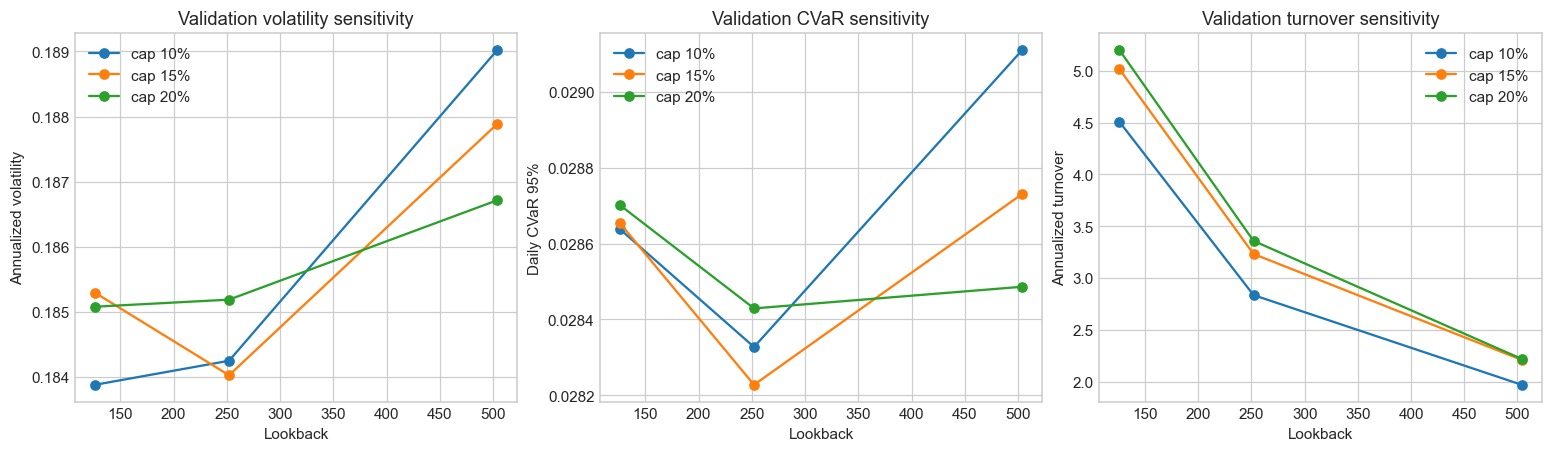

In [21]:
monthly_grid = validation_grid.query("rebalance == 'M'")
robustness_columns = [
    "lookback", "max_weight", "Annualized Volatility", "CVaR 95%",
    "Maximum Drawdown", "Annualized Turnover", "Average HHI", "Sharpe",
]
print("Validation-only robustness grid")
display(
    monthly_grid[robustness_columns]
    .sort_values(["lookback", "max_weight"])
    .style.format({
        "max_weight": "{:.0%}", "Annualized Volatility": "{:.2%}",
        "CVaR 95%": "{:.2%}", "Maximum Drawdown": "{:.2%}",
        "Annualized Turnover": "{:.2f}", "Average HHI": "{:.3f}", "Sharpe": "{:.3f}",
    })
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for max_weight, group in monthly_grid.groupby("max_weight"):
    ordered = group.sort_values("lookback")
    axes[0].plot(ordered["lookback"], ordered["Annualized Volatility"], marker="o", label=f"cap {max_weight:.0%}")
    axes[1].plot(ordered["lookback"], ordered["CVaR 95%"], marker="o", label=f"cap {max_weight:.0%}")
    axes[2].plot(ordered["lookback"], ordered["Annualized Turnover"], marker="o", label=f"cap {max_weight:.0%}")
axes[0].set(title="Validation volatility sensitivity", xlabel="Lookback", ylabel="Annualized volatility")
axes[1].set(title="Validation CVaR sensitivity", xlabel="Lookback", ylabel="Daily CVaR 95%")
axes[2].set(title="Validation turnover sensitivity", xlabel="Lookback", ylabel="Annualized turnover")
for axis in axes:
    axis.legend()
plt.show()

,mean_shrinkage,median_sample_condition,median_shrinkage_condition,mean_weights_at_cap,mean_active_positions,mean_effective_assets,solver_failures
period,,,,,,,
test,0.072,411.573,121.723,1.081,20.065,12.408,0.000
validation,0.082,420.759,147.593,1.167,21.021,12.989,0.000


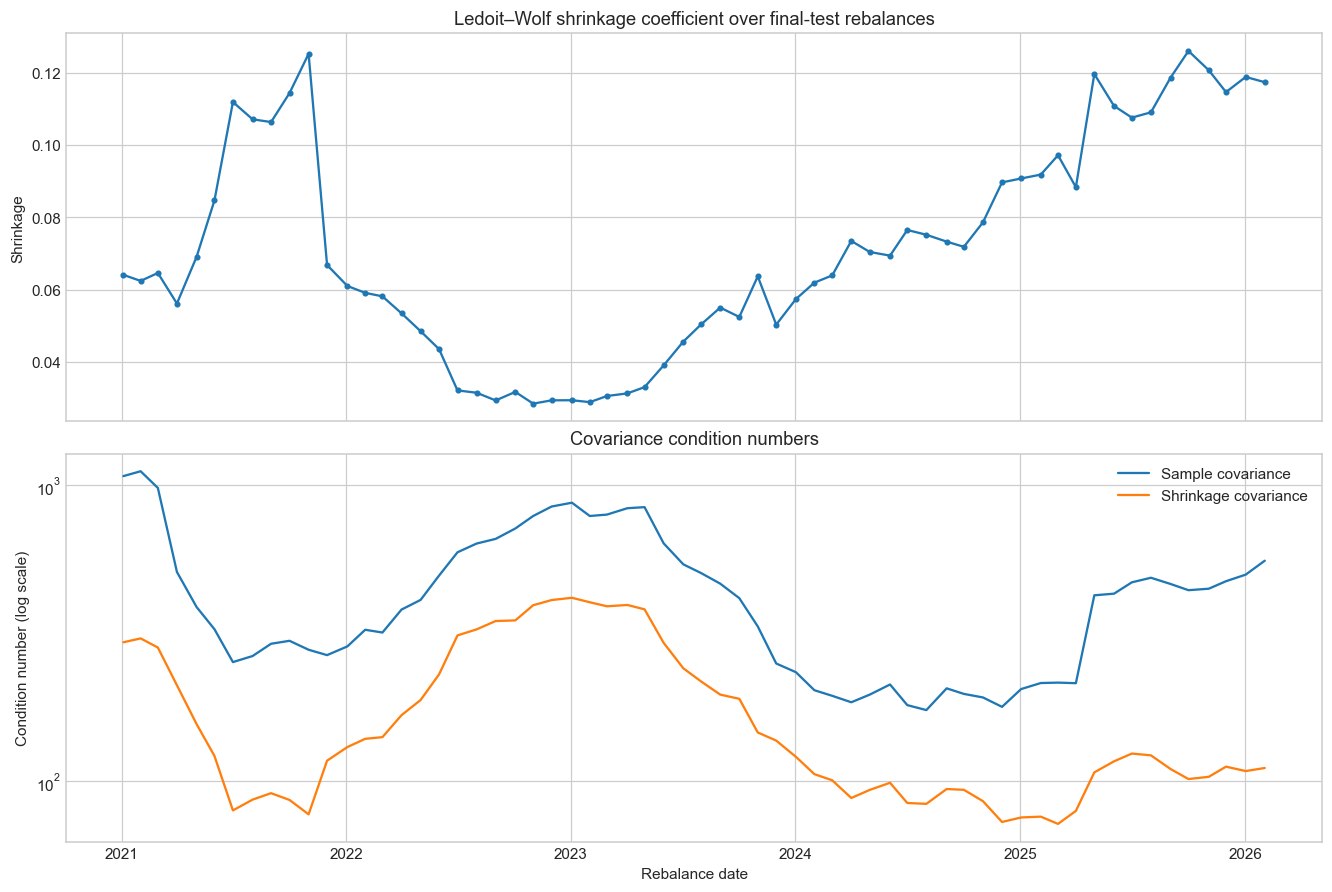

Shrinkage versus unregularized sample-GMV diagnostics — final test


,Annualized Volatility,CVaR 95%,Average Turnover,Annualized Turnover,Average HHI,Average Effective Assets,Mean Target L1 Change,Solver Failures
Shrinkage GMV,13.21%,1.86%,0.26,3.17,8.49%,12.41,0.248799,0.000000
Sample GMV (Diagnostic),13.23%,1.87%,0.28,3.39,9.50%,10.88,0.266441,0.000000


In [22]:
shrinkage_diagnostics = pd.concat(
    {"validation": validation_results["shrinkage_gmv"].diagnostics,
     "test": test_results["shrinkage_gmv"].diagnostics},
    names=["period", "rebalance_date"],
)
diagnostic_summary = shrinkage_diagnostics.groupby(level="period").agg(
    mean_shrinkage=("shrinkage", "mean"),
    median_sample_condition=("sample_condition_number", "median"),
    median_shrinkage_condition=("covariance_condition_number", "median"),
    mean_weights_at_cap=("weights_at_cap", "mean"),
    mean_active_positions=("active_positions", "mean"),
    mean_effective_assets=("effective_assets", "mean"),
    solver_failures=("fallback_used", "sum"),
)
display(diagnostic_summary.style.format("{:.3f}"))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
test_lw_diag = test_results["shrinkage_gmv"].diagnostics
axes[0].plot(test_lw_diag.index, test_lw_diag["shrinkage"], marker="o", ms=3)
axes[0].set(title="Ledoit–Wolf shrinkage coefficient over final-test rebalances", ylabel="Shrinkage")
axes[1].semilogy(test_lw_diag.index, test_lw_diag["sample_condition_number"], label="Sample covariance")
axes[1].semilogy(test_lw_diag.index, test_lw_diag["covariance_condition_number"], label="Shrinkage covariance")
axes[1].set(title="Covariance condition numbers", ylabel="Condition number (log scale)", xlabel="Rebalance date")
axes[1].legend()
plt.show()

stability_comparison = test_metrics_net.loc[
    ["Shrinkage GMV", "Sample GMV (Diagnostic)"],
    ["Annualized Volatility", "CVaR 95%", "Average Turnover", "Annualized Turnover",
     "Average HHI", "Average Effective Assets", "Mean Target L1 Change", "Solver Failures"],
]
print("Shrinkage versus unregularized sample-GMV diagnostics — final test")
display(compact_metric_table(stability_comparison))

In [23]:
reference_config = FROZEN_CONFIG
weight_sensitivity_rows = []
reference_result = validation_grid_results[reference_config.label]
for candidate in CANDIDATE_CONFIGS:
    if candidate.rebalance != reference_config.rebalance or candidate.max_weight != reference_config.max_weight:
        continue
    candidate_result = validation_grid_results[candidate.label]
    common_dates = reference_result.target_weights.index.intersection(candidate_result.target_weights.index)
    mean_l1_distance = (
        reference_result.target_weights.loc[common_dates]
        .sub(candidate_result.target_weights.loc[common_dates])
        .abs()
        .sum(axis=1)
        .mean()
    )
    metrics = calculate_performance_metrics(candidate_result, "net_return")
    weight_sensitivity_rows.append(
        {
            "lookback": candidate.lookback,
            "mean_target_L1_distance_to_frozen": mean_l1_distance,
            "annualized_volatility": metrics["Annualized Volatility"],
            "annualized_turnover": metrics["Annualized Turnover"],
            "average_effective_assets": metrics["Average Effective Assets"],
        }
    )
print("Validation weight sensitivity to lookback at the frozen cap/frequency")
display(pd.DataFrame(weight_sensitivity_rows).set_index("lookback").style.format({
    "mean_target_L1_distance_to_frozen": "{:.3f}", "annualized_volatility": "{:.2%}",
    "annualized_turnover": "{:.2f}", "average_effective_assets": "{:.2f}",
}))

Validation weight sensitivity to lookback at the frozen cap/frequency


,mean_target_L1_distance_to_frozen,annualized_volatility,annualized_turnover,average_effective_assets
lookback,,,,
126,0.542,18.53%,5.02,13.80
252,0.000,18.40%,3.23,12.99
504,0.546,18.79%,2.21,12.23


## 17. Point-in-Time Integrity and Leakage Audit

This experiment uses no random split. Every formation-date covariance window and eligibility decision ends strictly before the effective return date. Validation alone controls the frozen configuration; the test period is evaluated only afterward. All rolling diagnostics are backward-looking, and costs are charged exactly when target weights replace drifted pre-trade weights.

In [24]:
all_backtests = {
    **{f"validation_{key}": value for key, value in validation_results.items()},
    **{f"test_{key}": value for key, value in test_results.items()},
}
audit_records = [
    {
        "check": "Strict split chronology",
        "passed": bool(
            split_ranges.loc["train", "end"] < split_ranges.loc["validation", "start"]
            and split_ranges.loc["validation", "end"] < split_ranges.loc["test", "start"]
        ),
        "evidence": "max(train) < min(validation) and max(validation) < min(test)",
    },
    {
        "check": "Estimation data strictly precede weights",
        "passed": all(
            (result.diagnostics["history_end"] < result.diagnostics.index).all()
            for result in all_backtests.values()
        ),
        "evidence": "All recorded history_end values are earlier than rebalance_date",
    },
    {
        "check": "Validation-only model selection",
        "passed": CONFIG_SELECTION_SOURCE == "validation",
        "evidence": f"Frozen label {FROZEN_CONFIG.label} selected from validation_grid",
    },
    {
        "check": "No random temporal split",
        "passed": True,
        "evidence": "Source-provided chronological files are used unchanged",
    },
    {
        "check": "Dynamic backward-looking universe",
        "passed": True,
        "evidence": "get_eligible_universe filters returns/prices with index < formation_date",
    },
    {
        "check": "Costs applied on portfolio changes",
        "passed": all(
            np.allclose(
                result.returns["transaction_cost"],
                result.returns["turnover"] * result.config.cost_rate,
            )
            for result in all_backtests.values()
        ),
        "evidence": "cost = bps/10,000 × drift-adjusted two-sided L1 turnover",
    },
    {
        "check": "Complete evaluation-date coverage",
        "passed": all(
            result.returns.index.equals(
                split_dates["validation" if name.startswith("validation") else "test"]
            )
            for name, result in all_backtests.items()
        ),
        "evidence": "Every strategy has exactly one realized return per supplied evaluation date",
    },
    {
        "check": "Finite returns and feasible target weights",
        "passed": all(
            np.isfinite(result.returns.to_numpy(dtype=float)).all()
            and np.isfinite(result.target_weights.to_numpy(dtype=float)).all()
            and np.allclose(result.target_weights.sum(axis=1), 1.0, atol=1e-8)
            and result.target_weights.min().min() >= -1e-10
            and result.target_weights.max().max() <= result.config.max_weight + 1e-7
            for result in all_backtests.values()
        ),
        "evidence": "All saved returns/weights are finite; weights are long-only, sum to one, and respect the cap",
    },
    {
        "check": "Gross-to-net return reconciliation",
        "passed": all(
            np.allclose(
                result.returns["net_return"],
                result.returns["gross_return"] - result.returns["transaction_cost"],
            )
            for result in all_backtests.values()
        ),
        "evidence": "net return = gross return − formation-date transaction cost",
    },
    {
        "check": "Final-table cumulative-return reconciliation",
        "passed": all(
            np.isclose(
                (1.0 + result.returns["net_return"]).prod() - 1.0,
                test_metrics_net.loc[STRATEGY_LABELS[strategy], "Cumulative Return"],
            )
            for strategy, result in test_results.items()
        ),
        "evidence": "Displayed cumulative returns equal independently compounded net daily returns",
    },
]
leakage_audit = pd.DataFrame(audit_records).set_index("check")
display(leakage_audit)
assert leakage_audit["passed"].all(), "Point-in-time integrity audit failed."

,passed,evidence
check,,
Strict split chronology,True,max(train) < min(validation) and max(validatio...
Estimation data strictly precede weights,True,All recorded history_end values are earlier th...
Validation-only model selection,True,Frozen label LB252_M_CAP15 selected from valid...
No random temporal split,True,Source-provided chronological files are used u...
Dynamic backward-looking universe,True,get_eligible_universe filters returns/prices w...
Costs applied on portfolio changes,True,"cost = bps/10,000 × drift-adjusted two-sided L..."
Complete evaluation-date coverage,True,Every strategy has exactly one realized return...
Finite returns and feasible target weights,True,All saved returns/weights are finite; weights ...
Gross-to-net return reconciliation,True,net return = gross return − formation-date tra...


## 18. Baseline Findings

In [25]:
def relative_change(new_value: float, reference_value: float) -> float:
    """Return a signed relative change with explicit zero protection."""
    return new_value / reference_value - 1.0 if reference_value != 0 else np.nan


equal_metrics = test_metrics_net.loc["1/N"]
shrinkage_metrics = test_metrics_net.loc["Shrinkage GMV"]
sample_metrics = test_metrics_net.loc["Sample GMV (Diagnostic)"]

volatility_change = relative_change(
    shrinkage_metrics["Annualized Volatility"], equal_metrics["Annualized Volatility"]
)
cvar_change = relative_change(shrinkage_metrics["CVaR 95%"], equal_metrics["CVaR 95%"])
drawdown_change = relative_change(
    shrinkage_metrics["Maximum Drawdown"], equal_metrics["Maximum Drawdown"]
)
sharpe_difference = shrinkage_metrics["Sharpe"] - equal_metrics["Sharpe"]
sample_turnover_change = relative_change(
    shrinkage_metrics["Annualized Turnover"], sample_metrics["Annualized Turnover"]
)
sample_stability_change = relative_change(
    shrinkage_metrics["Mean Target L1 Change"], sample_metrics["Mean Target L1 Change"]
)

def risk_phrase(value: float) -> str:
    return "lower" if value < 0 else "higher"


ci_crosses_zero = {
    metric: paired_uncertainty.loc[metric, "lower_95"] <= 0 <= paired_uncertainty.loc[metric, "upper_95"]
    for metric in paired_uncertainty.index
}
uncertainty_sentence = (
    "The 95% paired block-bootstrap interval includes zero for at least one key risk difference, "
    "so numerical gaps should not be presented as definitive statistical superiority."
    if any(ci_crosses_zero[m] for m in ["Annualized Volatility", "CVaR 95%", "Maximum Drawdown"])
    else "The paired block-bootstrap intervals exclude zero for the reported key risk differences; economic magnitude and sample length still matter."
)

stability_judgment = (
    "operationally stable enough to serve as the control specification for the next regime-aware experiment"
    if shrinkage_metrics["Solver Failures"] == 0
    and shrinkage_metrics["Average Maximum Weight"] <= FROZEN_CONFIG.max_weight + 1e-6
    else "usable only with the solver/concentration caveats reported above before serving as the next experiment's control"
)

findings = f"""
**Frozen specification.** Validation selected `{FROZEN_CONFIG.label}`: a {FROZEN_CONFIG.lookback}-day lookback,
{'monthly' if FROZEN_CONFIG.rebalance == 'M' else 'quarterly'} rebalancing, a {FROZEN_CONFIG.max_weight:.0%} cap,
and {FROZEN_CONFIG.transaction_cost_bps:.0f} bps per dollar traded.

1. **Realized risk:** Shrinkage GMV test volatility was {shrinkage_metrics['Annualized Volatility']:.2%},
   {risk_phrase(volatility_change)} than 1/N's {equal_metrics['Annualized Volatility']:.2%}
   ({volatility_change:+.1%} relative).
2. **Tail risk:** daily CVaR 95% was {shrinkage_metrics['CVaR 95%']:.2%} versus
   {equal_metrics['CVaR 95%']:.2%} for 1/N ({cvar_change:+.1%} relative).
3. **Drawdown:** maximum drawdown was {shrinkage_metrics['Maximum Drawdown']:.2%} versus
   {equal_metrics['Maximum Drawdown']:.2%} ({drawdown_change:+.1%} relative).
4. **Risk-adjusted performance:** the test Sharpe difference was {sharpe_difference:+.3f}; this is a descriptive,
   non-causal comparison rather than proof of superiority.
5. **Implementation:** Shrinkage GMV annualized turnover was {shrinkage_metrics['Annualized Turnover']:.2f},
   producing total modeled transaction costs of {shrinkage_metrics['Total Transaction Costs']:.2%} over the test.
6. **Concentration:** average effective breadth was {shrinkage_metrics['Average Effective Assets']:.1f} assets and
   average maximum weight was {shrinkage_metrics['Average Maximum Weight']:.2%}; the explicit cap prevents a single unconstrained dominant position.
7. **Shrinkage diagnostic:** relative to Sample GMV, shrinkage changed annualized turnover by
   {sample_turnover_change:+.1%} and mean target-weight L1 instability by {sample_stability_change:+.1%}.
8. **Control-model assessment:** with {int(shrinkage_metrics['Solver Failures'])} test solver fallback(s), the frozen baseline is
   {stability_judgment}.

**Uncertainty.** {uncertainty_sentence} Statistical uncertainty and economic relevance are distinct; the supplied balanced panel also leaves residual survivorship-bias risk.
"""
display(Markdown(findings))


**Frozen specification.** Validation selected `LB252_M_CAP15`: a 252-day lookback,
monthly rebalancing, a 15% cap,
and 10 bps per dollar traded.

1. **Realized risk:** Shrinkage GMV test volatility was 13.21%,
   lower than 1/N's 16.92%
   (-21.9% relative).
2. **Tail risk:** daily CVaR 95% was 1.86% versus
   2.41% for 1/N (-22.8% relative).
3. **Drawdown:** maximum drawdown was 18.67% versus
   20.67% (-9.7% relative).
4. **Risk-adjusted performance:** the test Sharpe difference was -0.040; this is a descriptive,
   non-causal comparison rather than proof of superiority.
5. **Implementation:** Shrinkage GMV annualized turnover was 3.17,
   producing total modeled transaction costs of 1.62% over the test.
6. **Concentration:** average effective breadth was 12.4 assets and
   average maximum weight was 13.70%; the explicit cap prevents a single unconstrained dominant position.
7. **Shrinkage diagnostic:** relative to Sample GMV, shrinkage changed annualized turnover by
   -6.4% and mean target-weight L1 instability by -6.6%.
8. **Control-model assessment:** with 0 test solver fallback(s), the frozen baseline is
   operationally stable enough to serve as the control specification for the next regime-aware experiment.

**Uncertainty.** The 95% paired block-bootstrap interval includes zero for at least one key risk difference, so numerical gaps should not be presented as definitive statistical superiority. Statistical uncertainty and economic relevance are distinct; the supplied balanced panel also leaves residual survivorship-bias risk.


In [26]:
FINAL_COLUMNS = [
    "CAGR", "Annualized Volatility", "Sharpe", "Sortino", "Maximum Drawdown",
    "VaR 95%", "CVaR 95%", "Annualized Turnover", "Total Transaction Costs",
    "Average Effective Assets",
]
print("Final frozen test-period results — net of transaction costs")
display(compact_metric_table(test_metrics_net[FINAL_COLUMNS]))

Final frozen test-period results — net of transaction costs


,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,VaR 95%,CVaR 95%,Annualized Turnover,Total Transaction Costs,Average Effective Assets
1/N,12.47%,16.92%,0.779,1.128,20.67%,1.66%,2.41%,0.31,0.16%,50.00
Shrinkage GMV,9.29%,13.21%,0.739,1.054,18.67%,1.30%,1.86%,3.17,1.62%,12.41
Sample GMV (Diagnostic),9.40%,13.23%,0.745,1.063,18.93%,1.30%,1.87%,3.39,1.73%,10.88
